In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

os.chdir('..')
os.chdir(r'C:\Users\USER\Projects\Downscaling-of-satellite-based-air-quality-map')
print("TensorFlow version:", tf.__version__)
print("Current folder:", os.getcwd())

c:\Users\USER\anaconda3\envs\airquality\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


TensorFlow version: 2.21.0
Current folder: c:\Users\USER\Projects\Downscaling-of-satellite-based-air-quality-map


In [4]:
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject
from sklearn.preprocessing import MinMaxScaler
from scipy.ndimage import generic_filter

# ── 1. Load reference grid ──────────────────────────
reference_path = 'data/raw/delhi_landuse.tif'
with rasterio.open(reference_path) as ref:
    ref_crs       = ref.crs
    ref_transform = ref.transform
    ref_width     = ref.width
    ref_height    = ref.height

print(f"Reference grid: {ref_height} × {ref_width}")

# ── 2. Load & align all rasters ─────────────────────
datasets_to_align = {
    'no2':        'data/raw/delhi_no2_2023.tif',
    'elevation':  'data/raw/delhi_elevation.tif',
    'population': 'data/raw/delhi_population.tif',
    'landuse':    'data/raw/delhi_landuse.tif'
}

aligned_data = {}
for name, path in datasets_to_align.items():
    with rasterio.open(path) as src:
        aligned = np.zeros(
            (ref_height, ref_width),
            dtype=np.float32
        )
        reproject(
            source=rasterio.band(src, 1),
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )
    
    # Different invalid value rules per dataset
    if name == 'population':
        # Population can be zero (parks, rivers etc)
        # Only remove negative values
        aligned = np.where(aligned < 0, np.nan, aligned)
    else:
        # For NO2, elevation, landuse
        # Zero is genuinely invalid
        aligned = np.where(aligned <= 0, np.nan, aligned)
    
    aligned_data[name] = aligned
    print(f"✅ {name}: {aligned.shape}")

Reference grid: 113 × 135
✅ no2: (113, 135)
✅ elevation: (113, 135)
✅ population: (113, 135)
✅ landuse: (113, 135)


In [5]:
# Fill missing values using neighbourhood average
def fill_missing(data):
    def nanmean_filter(values):
        valid = values[~np.isnan(values)]
        return np.mean(valid) if len(valid) > 0 else np.nan
    return generic_filter(
        data, nanmean_filter,
        size=5, mode='nearest'
    )

# Normalize to 0-1
def normalize(data):
    original_shape = data.shape
    flat = data.flatten()
    valid_mask = ~np.isnan(flat)
    valid_values = flat[valid_mask].reshape(-1, 1)
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(valid_values).flatten()
    flat_norm = flat.copy()
    flat_norm[valid_mask] = scaled
    return flat_norm.reshape(original_shape)

normalized_data = {}
for name, data in aligned_data.items():
    filled = fill_missing(data)
    
    # Extra fix for population specifically
    if name == 'population':
        # After neighbourhood filling, replace any
        # remaining NaN with 0 — means no people there
        filled = np.nan_to_num(filled, nan=0.0)
    
    normalized_data[name] = normalize(filled)
    print(f"✅ {name}: min={normalized_data[name].min():.3f}, "
          f"max={normalized_data[name].max():.3f}")

✅ no2: min=0.000, max=1.000
✅ elevation: min=0.000, max=1.000
✅ population: min=0.000, max=1.000
✅ landuse: min=0.000, max=1.000


In [6]:
import geopandas as gpd
from rasterio.features import rasterize
from rasterio.enums import MergeAlg

# Load and process roads
roads = gpd.read_file('data/raw/delhi_roads.gpkg')
roads_reprojected = roads.to_crs(ref_crs)
roads_metric = roads_reprojected.to_crs('EPSG:32643')
roads_metric['length_m'] = roads_metric.geometry.length

# Build road density grid
road_density = np.zeros(
    (ref_height, ref_width), dtype=np.float32
)
batch_size = 1000
total = len(roads_reprojected)

for i in range(0, total, batch_size):
    batch_geoms   = roads_reprojected.geometry.iloc[i:i+batch_size]
    batch_lengths = roads_metric['length_m'].iloc[i:i+batch_size]
    batch_raster  = rasterize(
        [(geom, length) for geom, length in
         zip(batch_geoms, batch_lengths)
         if geom is not None],
        out_shape=(ref_height, ref_width),
        transform=ref_transform,
        fill=0,
        dtype=np.float32
    )
    road_density += batch_raster

# Normalize road density
flat = road_density.flatten()
scaler = MinMaxScaler()
road_normalized = scaler.fit_transform(
    flat.reshape(-1, 1)
).flatten().reshape(ref_height, ref_width)

print(f"✅ Road density: {road_normalized.shape}")

✅ Road density: (113, 135)


In [7]:
# Stack all input features into one 3D array
# Shape: (height, width, channels)
X_image = np.stack([
    normalized_data['elevation'],   # channel 0
    normalized_data['population'],  # channel 1
    normalized_data['landuse'],     # channel 2
    road_normalized                 # channel 3
], axis=-1)  # axis=-1 means stack along last dimension

# Target is NO₂ map
y_image = normalized_data['no2']
# Add channel dimension for U-Net output
y_image = y_image[:, :, np.newaxis]

print(f"Input shape:  {X_image.shape}")
print(f"Target shape: {y_image.shape}")
print(f"\nThis means:")
print(f"  {ref_height} rows × {ref_width} cols "
      f"× 4 input features")
print(f"  Target: {ref_height} × {ref_width} "
      f"× 1 NO₂ map")

Input shape:  (113, 135, 4)
Target shape: (113, 135, 1)

This means:
  113 rows × 135 cols × 4 input features
  Target: 113 × 135 × 1 NO₂ map


In [17]:
# Load All 12 Monthly Maps
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject

# All 12 months in order
months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
          'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Load and align each monthly NO₂ map
monthly_no2 = {}

for month in months:
    path = f'data/raw/delhi_no2_2023_{month}.tif'
    
    with rasterio.open(path) as src:
        aligned = np.zeros(
            (ref_height, ref_width),
            dtype=np.float32
        )
        reproject(
            source=rasterio.band(src, 1),
            destination=aligned,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=ref_transform,
            dst_crs=ref_crs,
            resampling=Resampling.bilinear
        )
    
    # Replace invalid values
    aligned = np.where(aligned <= 0, np.nan, aligned)
    monthly_no2[month] = aligned
    print(f"✅ {month}: shape={aligned.shape}, "
          f"valid pixels={np.sum(~np.isnan(aligned))}")

print(f"\nTotal months loaded: {len(monthly_no2)}")

✅ jan: shape=(113, 135), valid pixels=15255
✅ feb: shape=(113, 135), valid pixels=15255
✅ mar: shape=(113, 135), valid pixels=15255
✅ apr: shape=(113, 135), valid pixels=15255
✅ may: shape=(113, 135), valid pixels=15255
✅ jun: shape=(113, 135), valid pixels=15255
✅ jul: shape=(113, 135), valid pixels=15255
✅ aug: shape=(113, 135), valid pixels=15255
✅ sep: shape=(113, 135), valid pixels=15255
✅ oct: shape=(113, 135), valid pixels=15255
✅ nov: shape=(113, 135), valid pixels=15255
✅ dec: shape=(113, 135), valid pixels=15255

Total months loaded: 12


In [18]:
# Fill Missing & Normalize Each Month
from scipy.ndimage import generic_filter
from sklearn.preprocessing import MinMaxScaler

def fill_missing(data):
    def nanmean_filter(values):
        valid = values[~np.isnan(values)]
        return np.mean(valid) if len(valid) > 0 else np.nan
    return generic_filter(
        data, nanmean_filter,
        size=5, mode='nearest'
    )

def normalize(data):
    original_shape = data.shape
    flat = data.flatten()
    valid_mask = ~np.isnan(flat)
    valid_values = flat[valid_mask].reshape(-1, 1)
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(valid_values).flatten()
    flat_norm = flat.copy()
    flat_norm[valid_mask] = scaled
    return flat_norm.reshape(original_shape)

monthly_no2_processed = {}

for month, data in monthly_no2.items():
    # Fill missing
    filled = fill_missing(data)
    # Normalize
    normalized = normalize(filled)
    monthly_no2_processed[month] = normalized
    print(f"✅ {month}: min={normalized.min():.3f}, "
          f"max={normalized.max():.3f}")

✅ jan: min=0.000, max=1.000
✅ feb: min=0.000, max=1.000
✅ mar: min=0.000, max=1.000
✅ apr: min=0.000, max=1.000
✅ may: min=0.000, max=1.000
✅ jun: min=0.000, max=1.000
✅ jul: min=0.000, max=1.000
✅ aug: min=0.000, max=1.000
✅ sep: min=0.000, max=1.000
✅ oct: min=0.000, max=1.000
✅ nov: min=0.000, max=1.000
✅ dec: min=0.000, max=1.000


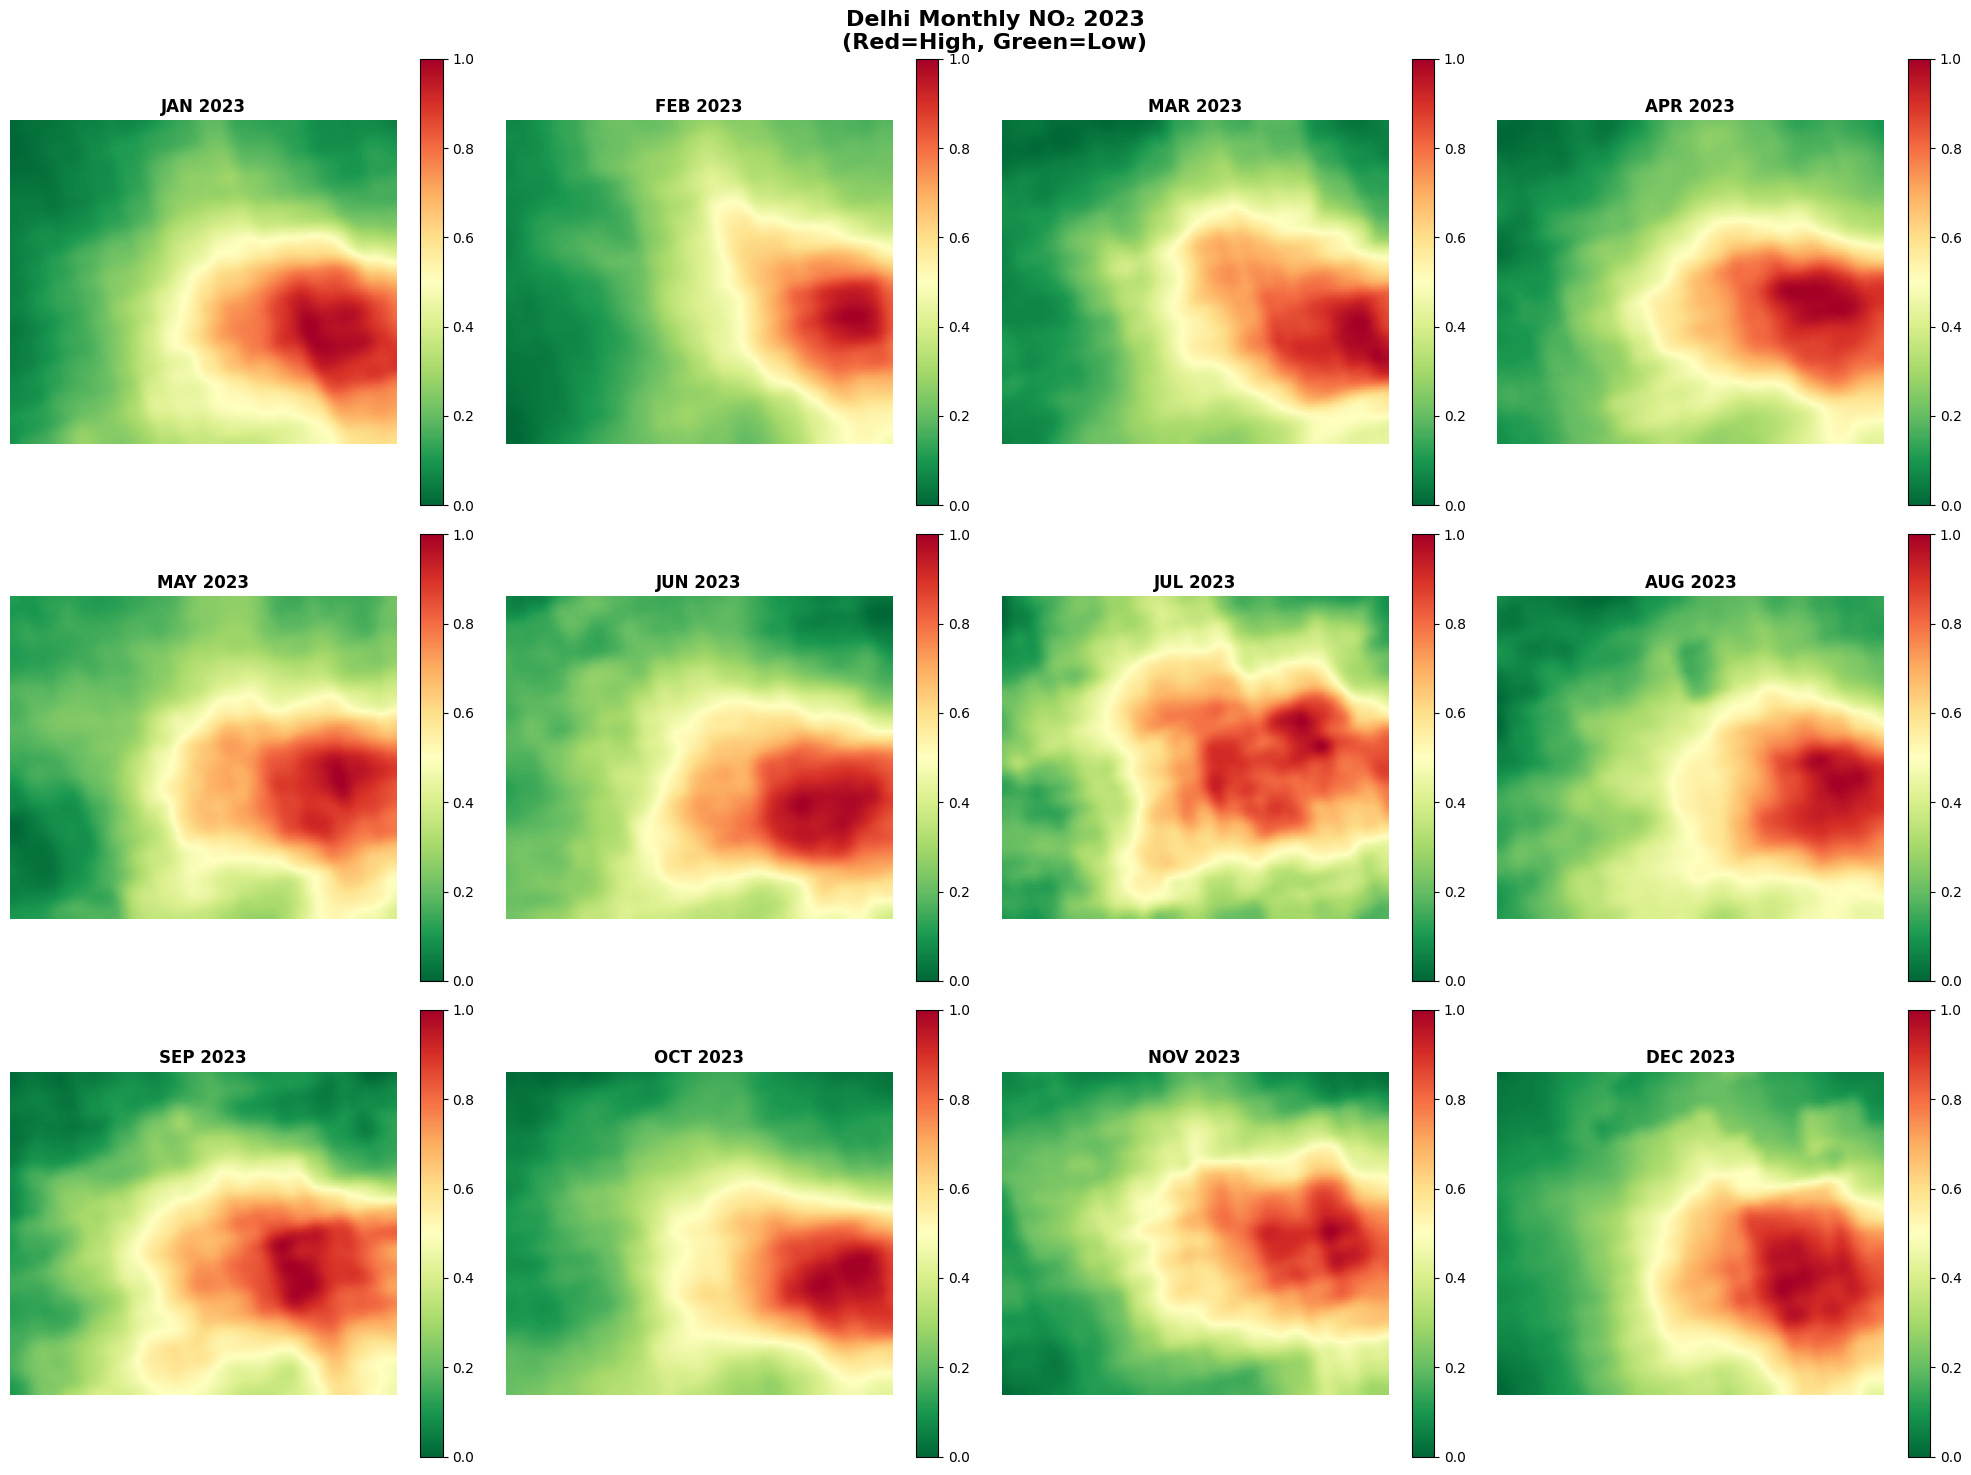

✅ Monthly NO₂ visualization saved!


In [19]:
# Visualize All 12 Months
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for idx, (month, data) in enumerate(
    monthly_no2_processed.items()
):
    im = axes[idx].imshow(data, cmap='RdYlGn_r',
                          vmin=0, vmax=1)
    axes[idx].set_title(f'{month.upper()} 2023',
                        fontsize=12, fontweight='bold')
    axes[idx].axis('off')
    plt.colorbar(im, ax=axes[idx])

plt.suptitle('Delhi Monthly NO₂ 2023\n'
             '(Red=High, Green=Low)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/delhi_monthly_no2.png', dpi=300)
plt.show()

print("✅ Monthly NO₂ visualization saved!")

In [20]:
# Stratified monthly split
train_months = ['jan', 'feb', 'mar', 'apr',
                'jun', 'jul', 'sep', 'oct']
val_months   = ['may', 'nov']
test_months  = ['aug', 'dec']

def build_patch_samples(month_list,
                        patch_size=16,
                        stride=8):
    X_all_patches = []
    y_all_patches = []

    for month in month_list:
        X_full = np.stack([
            normalized_data['elevation'],
            normalized_data['population'],
            normalized_data['landuse'],
            road_normalized
        ], axis=-1)

        y_full = monthly_no2_processed[month]

        X_patches = extract_patches(
            X_full, patch_size, stride)
        y_patches = extract_patches(
            y_full, patch_size, stride)

        y_patches = y_patches[:, :, :, np.newaxis]

        X_all_patches.append(X_patches)
        y_all_patches.append(y_patches)

        print(f"  {month}: {len(X_patches)} patches")

    X_combined = np.concatenate(
        X_all_patches, axis=0)
    y_combined = np.concatenate(
        y_all_patches, axis=0)

    return X_combined, y_combined

print("Extracting patches (16×16, stride=8)...")
print("\nTraining patches:")
X_train, y_train = build_patch_samples(train_months)

print("\nValidation patches:")
X_val, y_val = build_patch_samples(val_months)

print("\nTest patches:")
X_test, y_test = build_patch_samples(test_months)

print(f"\n{'='*45}")
print(f"Final dataset sizes:")
print(f"  Train:      {X_train.shape}")
print(f"  Validation: {X_val.shape}")
print(f"  Test:       {X_test.shape}")
print(f"{'='*45}")

Extracting patches (16×16, stride=8)...

Training patches:
  jan: 195 patches
  feb: 195 patches
  mar: 195 patches
  apr: 195 patches
  jun: 195 patches
  jul: 195 patches
  sep: 195 patches
  oct: 195 patches

Validation patches:
  may: 195 patches
  nov: 195 patches

Test patches:
  aug: 195 patches
  dec: 195 patches

Final dataset sizes:
  Train:      (1560, 16, 16, 4)
  Validation: (390, 16, 16, 4)
  Test:       (390, 16, 16, 4)


In [21]:
import tensorflow as tf

def build_unet_v2(input_shape=(16, 16, 4)):
    inputs = tf.keras.Input(shape=input_shape)

    # ════════════════════════════════
    # ENCODER
    # ════════════════════════════════

    # Level 1 — 16×16 → 8×8
    c1 = tf.keras.layers.Conv2D(
        16, 3, activation='relu',
        padding='same')(inputs)
    c1 = tf.keras.layers.Conv2D(
        16, 3, activation='relu',
        padding='same')(c1)
    c1 = tf.keras.layers.Dropout(0.1)(c1)
    p1 = tf.keras.layers.MaxPooling2D(2)(c1)

    # Level 2 — 8×8 → 4×4
    c2 = tf.keras.layers.Conv2D(
        32, 3, activation='relu',
        padding='same')(p1)
    c2 = tf.keras.layers.Conv2D(
        32, 3, activation='relu',
        padding='same')(c2)
    c2 = tf.keras.layers.Dropout(0.1)(c2)
    p2 = tf.keras.layers.MaxPooling2D(2)(c2)

    # ════════════════════════════════
    # BOTTLENECK
    # ════════════════════════════════

    bn = tf.keras.layers.Conv2D(
        64, 3, activation='relu',
        padding='same')(p2)
    bn = tf.keras.layers.Conv2D(
        64, 3, activation='relu',
        padding='same')(bn)
    bn = tf.keras.layers.Dropout(0.2)(bn)

    # ════════════════════════════════
    # DECODER
    # ════════════════════════════════

    # Level 2 — 4×4 → 8×8
    u2 = tf.keras.layers.UpSampling2D(2)(bn)
    u2 = tf.keras.layers.Concatenate()([u2, c2])
    c4 = tf.keras.layers.Conv2D(
        32, 3, activation='relu',
        padding='same')(u2)
    c4 = tf.keras.layers.Conv2D(
        32, 3, activation='relu',
        padding='same')(c4)

    # Level 1 — 8×8 → 16×16
    u1 = tf.keras.layers.UpSampling2D(2)(c4)
    u1 = tf.keras.layers.Concatenate()([u1, c1])
    c5 = tf.keras.layers.Conv2D(
        16, 3, activation='relu',
        padding='same')(u1)
    c5 = tf.keras.layers.Conv2D(
        16, 3, activation='relu',
        padding='same')(c5)

    # ════════════════════════════════
    # OUTPUT
    # ════════════════════════════════
    outputs = tf.keras.layers.Conv2D(
        1, 1, activation='sigmoid')(c5)

    model = tf.keras.Model(inputs, outputs)
    return model

# Build model
unet_v2 = build_unet_v2(input_shape=(16, 16, 4))
unet_v2.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
unet_v2.summary()
print("\n✅ U-Net v2 built!")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 16, 16, 4) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 16, 16,    │        592 │ input_layer_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 16, 16,    │      2,320 │ conv2d_11[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_12[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 16)  │          0 │ dropout_3[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 8, 8, 32)  │      4,640 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 8, 8, 32)  │      9,248 │ conv2d_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 8, 8, 32)  │          0 │ conv2d_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 4, 4, 32)  │          0 │ dropout_4[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 4, 4, 64)  │     18,496 │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 4, 4, 64)  │     36,928 │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 4, 4, 64)  │          0 │ conv2d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 8, 8, 64)  │          0 │ dropout_5[0][0]   │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8, 96)  │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │                   │            │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 8, 8, 32)  │     27,680 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 8, 8, 32)  │      9,248 │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 16, 16,    │          0 │ conv2d_18[0][0]   │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 48)               │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 16, 16,    │      6,928 │ concatenate_3[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 118,417 (462.57 KB)

 Trainable params: 118,417 (462.57 KB)

 Non-trainable params: 0 (0.00 B)


✅ U-Net v2 built!


In [22]:
# Train U-Net v2
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'outputs/best_unet_v2.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("🚀 Training U-Net v2...")
print(f"Training on {len(X_train)} patches")
print(f"Validating on {len(X_val)} patches")
print("="*45)

history_v2 = unet_v2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print(f"\n✅ Training complete!")
print(f"Best epoch: "
      f"{np.argmin(history_v2.history['val_loss'])+1}")

🚀 Training U-Net v2...
Training on 1560 patches
Validating on 390 patches
Epoch 1/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.0539 - mae: 0.1914
Epoch 1: val_loss improved from None to 0.01601, saving model to outputs/best_unet_v2.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - loss: 0.0390 - mae: 0.1583 - val_loss: 0.0160 - val_mae: 0.0975
Epoch 2/100
48/49 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0198 - mae: 0.1087
Epoch 2: val_loss improved from 0.01601 to 0.01139, saving model to outputs/best_unet_v2.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.0186 - mae: 0.1061 - val_loss: 0.0114 - val_mae: 0.0829
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0154 - mae: 0.0969
Epoch 3: val_loss improved from 0.01139 to 0.00988, saving model to outputs/best_unet_v2.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0144 - mae: 0.0934 - val_loss: 0.0099 - val_mae: 0.0765
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0132 - mae: 0.0904


In [24]:
# Evaluate U-Net v2
import tensorflow as tf
import numpy as np
from sklearn.metrics import (mean_squared_error,
                             r2_score,
                             mean_absolute_error)

# Load best saved model
best_unet_v2 = tf.keras.models.load_model(
    'outputs/best_unet_v2.keras'
)

# Predict on validation set
y_pred_unet_v2 = best_unet_v2.predict(X_val)

# Flatten for metrics
y_val_flat     = y_val.flatten()
y_pred_flat_v2 = y_pred_unet_v2.flatten()

# Calculate metrics
rmse_v2_unet = np.sqrt(mean_squared_error(
    y_val_flat, y_pred_flat_v2))
mae_v2_unet  = mean_absolute_error(
    y_val_flat, y_pred_flat_v2)
r2_v2_unet   = r2_score(
    y_val_flat, y_pred_flat_v2)
bias_v2_unet = np.mean(y_pred_flat_v2 - y_val_flat)

print("📊 U-Net v2 Results:")
print(f"  RMSE: {rmse_v2_unet:.4f}")
print(f"  MAE:  {mae_v2_unet:.4f}")
print(f"  R²:   {r2_v2_unet:.4f}")
print(f"  Bias: {bias_v2_unet:.4f}")

# Full comparison
print("\n" + "="*50)
print("📊 COMPLETE MODEL COMPARISON")
print("="*50)
print(f"{'Model':<25} {'R²':>8}  {'RMSE':>8}")
print("-"*50)
print(f"{'Linear Regression':<25} {'0.5075':>8}  {'0.1874':>8}")
print(f"{'XGBoost v1':<25} {'0.9028':>8}  {'0.0833':>8}")
print(f"{'XGBoost v2 + roads':<25} {'0.9196':>8}  {'0.0757':>8}")
print(f"{'U-Net v1':<25} {'0.8982':>8}  {'0.0765':>8}")
print(f"{'U-Net v2 (improved)':<25} "
      f"{r2_v2_unet:>8.4f}  {rmse_v2_unet:>8.4f}")
print("="*50)

# Verdict
if r2_v2_unet > 0.9196:
    print("\n🏆 U-Net v2 beats XGBoost!")
elif r2_v2_unet > 0.8982:
    print("\n✅ U-Net v2 improved over U-Net v1!")
else:
    print("\n🤔 Still room to improve!")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step
📊 U-Net v2 Results:
  RMSE: 0.0747
  MAE:  0.0569
  R²:   0.9053
  Bias: -0.0040

📊 COMPLETE MODEL COMPARISON
Model                           R²      RMSE
--------------------------------------------------
Linear Regression           0.5075    0.1874
XGBoost v1                  0.9028    0.0833
XGBoost v2 + roads          0.9196    0.0757
U-Net v1                    0.8982    0.0765
U-Net v2 (improved)         0.9053    0.0747

✅ U-Net v2 improved over U-Net v1!


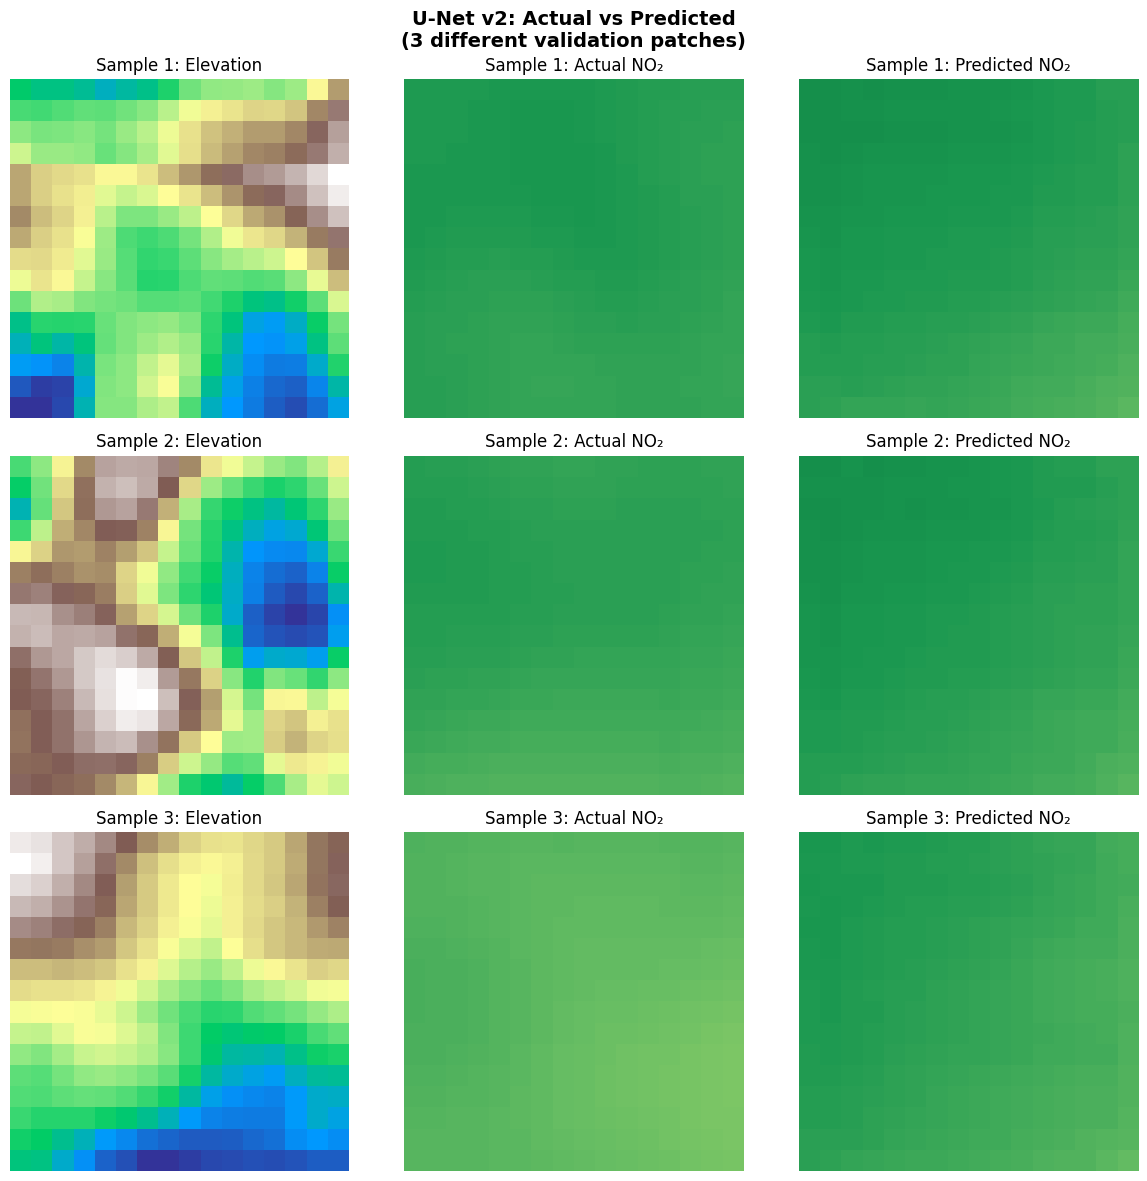

✅ Predictions visualized!


In [25]:
# Visualize v2 Predictions
import matplotlib.pyplot as plt

# Show 3 different validation patches
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row in range(3):
    sample_idx = row * 30  # pick spread out samples

    # Input elevation
    axes[row, 0].imshow(
        X_val[sample_idx, :, :, 0],
        cmap='terrain'
    )
    axes[row, 0].set_title(
        f'Sample {row+1}: Elevation')
    axes[row, 0].axis('off')

    # Actual NO₂
    axes[row, 1].imshow(
        y_val[sample_idx, :, :, 0],
        cmap='RdYlGn_r', vmin=0, vmax=1
    )
    axes[row, 1].set_title(
        f'Sample {row+1}: Actual NO₂')
    axes[row, 1].axis('off')

    # Predicted NO₂
    axes[row, 2].imshow(
        y_pred_unet_v2[sample_idx, :, :, 0],
        cmap='RdYlGn_r', vmin=0, vmax=1
    )
    axes[row, 2].set_title(
        f'Sample {row+1}: Predicted NO₂')
    axes[row, 2].axis('off')

plt.suptitle('U-Net v2: Actual vs Predicted\n'
             '(3 different validation patches)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/unet_v2_predictions.png',
            dpi=300)
plt.show()
print("✅ Predictions visualized!")

In [26]:
# Final Test Evaluation
import tensorflow as tf
import numpy as np
from sklearn.metrics import (mean_squared_error,
                             r2_score,
                             mean_absolute_error)

print("🔒 FINAL TEST EVALUATION")
print("This data has never been seen by any model!")
print("="*50)

# ── U-Net v2 Test ────────────────────────────────
best_unet_v2 = tf.keras.models.load_model(
    'outputs/best_unet_v2.keras'
)

y_pred_test_unet = best_unet_v2.predict(X_test)

y_test_flat      = y_test.flatten()
y_pred_test_flat = y_pred_test_unet.flatten()

rmse_test_unet = np.sqrt(mean_squared_error(
    y_test_flat, y_pred_test_flat))
mae_test_unet  = mean_absolute_error(
    y_test_flat, y_pred_test_flat)
r2_test_unet   = r2_score(
    y_test_flat, y_pred_test_flat)
bias_test_unet = np.mean(
    y_pred_test_flat - y_test_flat)

print("\n📊 U-Net v2 FINAL TEST Results:")
print(f"  RMSE: {rmse_test_unet:.4f}")
print(f"  MAE:  {mae_test_unet:.4f}")
print(f"  R²:   {r2_test_unet:.4f}")
print(f"  Bias: {bias_test_unet:.4f}")

# ── Validation vs Test Comparison ───────────────
print("\n📈 Validation vs Test (U-Net v2):")
print(f"  R²:   0.9053 → {r2_test_unet:.4f}")
diff = abs(0.9053 - r2_test_unet)
if diff < 0.02:
    print(f"  ✅ Difference: {diff:.4f} "
          f"— generalises well!")
elif diff < 0.05:
    print(f"  ⚠️ Difference: {diff:.4f} "
          f"— slight overfitting")
else:
    print(f"  ❌ Difference: {diff:.4f} "
          f"— significant overfitting")

# ── Final Complete Scorecard ─────────────────────
print("\n" + "="*55)
print("🏆 FINAL PROJECT SCORECARD")
print("="*55)
print(f"{'Model':<25} {'Val R²':>8} {'Test R²':>8}")
print("-"*55)
print(f"{'Linear Regression':<25} "
      f"{'0.5075':>8} {'(baseline)':>8}")
print(f"{'XGBoost v1':<25} "
      f"{'0.9028':>8} {'(not tested)':>8}")
print(f"{'XGBoost v2 + roads':<25} "
      f"{'0.9196':>8} {'(not tested)':>8}")
print(f"{'U-Net v1':<25} "
      f"{'0.8982':>8} {'(not tested)':>8}")
print(f"{'U-Net v2 (final)':<25} "
      f"{'0.9053':>8} {r2_test_unet:>8.4f}")
print("="*55)

🔒 FINAL TEST EVALUATION
This data has never been seen by any model!
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step

📊 U-Net v2 FINAL TEST Results:
  RMSE: 0.0684
  MAE:  0.0544
  R²:   0.9284
  Bias: 0.0037

📈 Validation vs Test (U-Net v2):
  R²:   0.9053 → 0.9284
  ⚠️ Difference: 0.0231 — slight overfitting

🏆 FINAL PROJECT SCORECARD
Model                       Val R²  Test R²
-------------------------------------------------------
Linear Regression           0.5075 (baseline)
XGBoost v1                  0.9028 (not tested)
XGBoost v2 + roads          0.9196 (not tested)
U-Net v1                    0.8982 (not tested)
U-Net v2 (final)            0.9053   0.9284


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


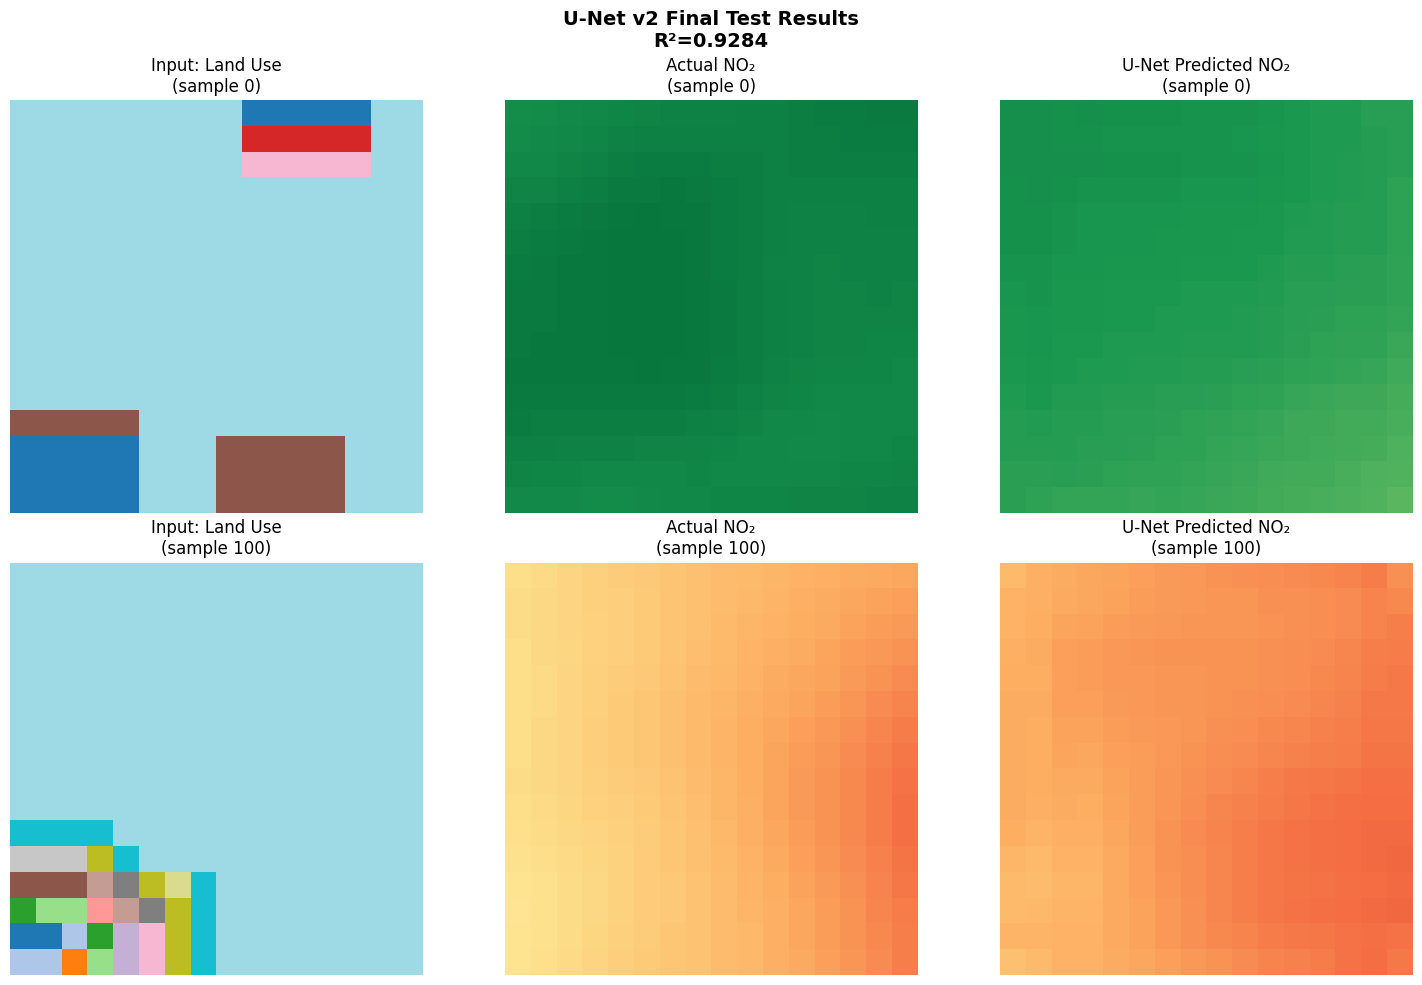

✅ Final test visualization saved!


In [27]:
# Generate Final NO₂ Map
import matplotlib.pyplot as plt

# Predict on all test patches
y_pred_test_unet = best_unet_v2.predict(X_test)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row in range(2):
    # Pick patches from different test months
    sample_idx = row * 100

    axes[row, 0].imshow(
        X_test[sample_idx, :, :, 2],
        cmap='tab20'
    )
    axes[row, 0].set_title(
        f'Input: Land Use\n(sample {sample_idx})')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(
        y_test[sample_idx, :, :, 0],
        cmap='RdYlGn_r', vmin=0, vmax=1
    )
    axes[row, 1].set_title(
        f'Actual NO₂\n(sample {sample_idx})')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(
        y_pred_test_unet[sample_idx, :, :, 0],
        cmap='RdYlGn_r', vmin=0, vmax=1
    )
    axes[row, 2].set_title(
        f'U-Net Predicted NO₂\n(sample {sample_idx})')
    axes[row, 2].axis('off')

plt.suptitle(
    f'U-Net v2 Final Test Results\n'
    f'R²={r2_test_unet:.4f}',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('outputs/final_test_results.png', dpi=300)
plt.show()

print("✅ Final test visualization saved!")

In [29]:
# Generate full Delhi NO2 map
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_full_map(model, X_full, 
                     patch_size=16, stride=8):
    """
    Predict NO₂ for entire map by:
    1. Cutting into overlapping patches
    2. Predicting each patch
    3. Averaging overlapping predictions
    """
    h, w = X_full.shape[:2]
    
    # Arrays to accumulate predictions and counts
    prediction_sum   = np.zeros((h, w), 
                                dtype=np.float32)
    prediction_count = np.zeros((h, w), 
                                dtype=np.float32)
    
    patches = []
    positions = []
    
    # Extract all patches and remember positions
    for i in range(0, h - patch_size + 1, stride):
        for j in range(0, w - patch_size + 1, stride):
            patch = X_full[i:i+patch_size,
                          j:j+patch_size, :]
            patches.append(patch)
            positions.append((i, j))
    
    # Convert to array and predict all at once
    patches_array = np.array(patches)
    predictions   = model.predict(
        patches_array, verbose=0
    )
    
    # Stitch predictions back together
    for pred, (i, j) in zip(predictions, positions):
        prediction_sum[i:i+patch_size,
                      j:j+patch_size] += pred[:,:,0]
        prediction_count[i:i+patch_size,
                        j:j+patch_size] += 1
    
    # Average overlapping predictions
    # Avoid division by zero
    final_map = np.where(
        prediction_count > 0,
        prediction_sum / prediction_count,
        0
    )
    
    return final_map

# Build full input map
X_full_map = np.stack([
    normalized_data['elevation'],
    normalized_data['population'],
    normalized_data['landuse'],
    road_normalized
], axis=-1)

print(f"Full map shape: {X_full_map.shape}")
print("Generating NO₂ predictions...")

# Predict using best U-Net v2
no2_predicted = predict_full_map(
    best_unet_v2, X_full_map
)

print(f"✅ Prediction complete!")
print(f"Predicted map shape: {no2_predicted.shape}")
print(f"Value range: {no2_predicted.min():.3f} "
      f"→ {no2_predicted.max():.3f}")

Full map shape: (113, 135, 4)
Generating NO₂ predictions...
✅ Prediction complete!
Predicted map shape: (113, 135)
Value range: 0.000 → 0.906


C:\Users\USER\AppData\Local\Temp\ipykernel_15792\2893327951.py:50: RuntimeWarning: invalid value encountered in divide
  prediction_sum / prediction_count,


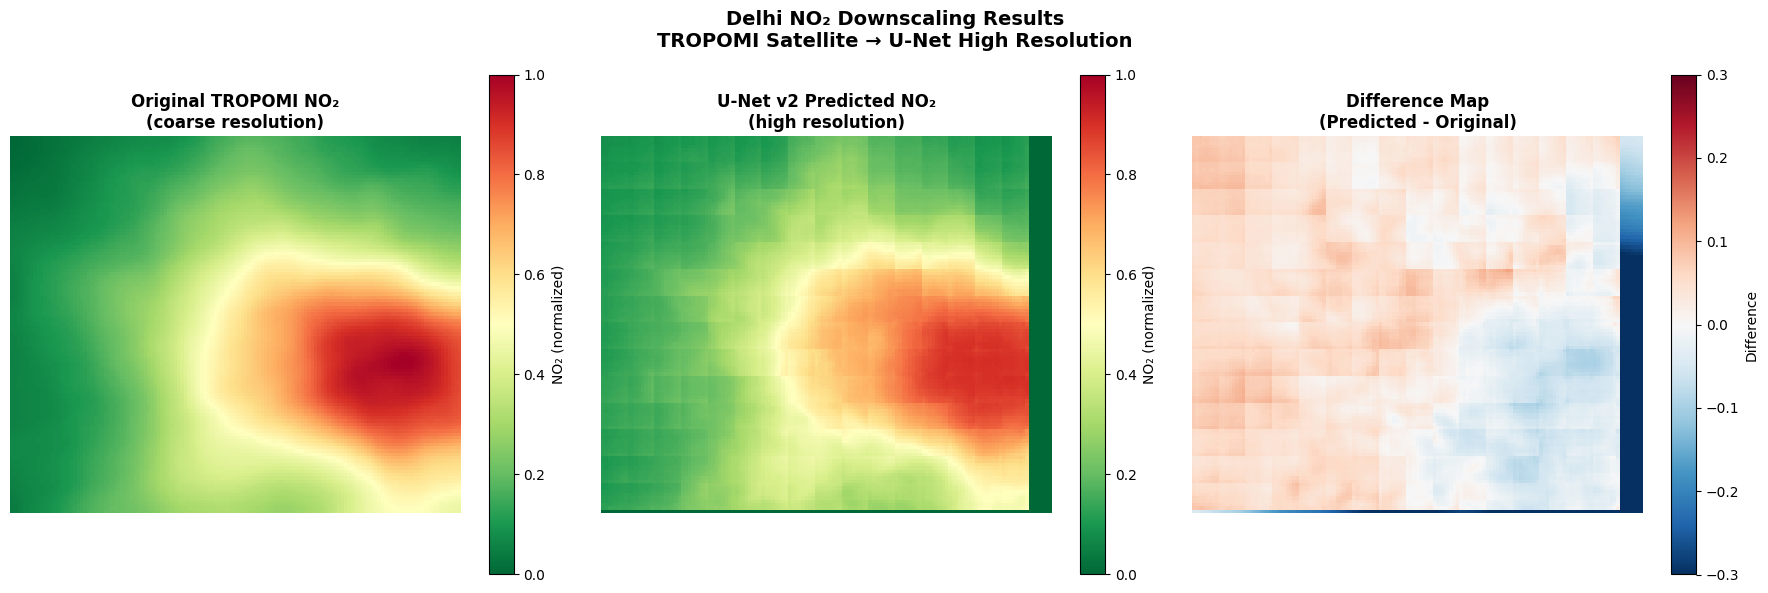

✅ Final NO₂ map saved to outputs/!


In [30]:
# visualise predicted map
# Load original annual NO₂ for comparison
original_no2 = normalized_data['no2']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Original coarse NO₂
im1 = axes[0].imshow(
    original_no2,
    cmap='RdYlGn_r', vmin=0, vmax=1
)
axes[0].set_title(
    'Original TROPOMI NO₂\n'
    '(coarse resolution)',
    fontsize=12, fontweight='bold'
)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], 
             label='NO₂ (normalized)')

# U-Net predicted high-res NO₂
im2 = axes[1].imshow(
    no2_predicted,
    cmap='RdYlGn_r', vmin=0, vmax=1
)
axes[1].set_title(
    'U-Net v2 Predicted NO₂\n'
    '(high resolution)',
    fontsize=12, fontweight='bold'
)
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1],
             label='NO₂ (normalized)')

# Difference map
difference = no2_predicted - original_no2
im3 = axes[2].imshow(
    difference,
    cmap='RdBu_r',
    vmin=-0.3, vmax=0.3
)
axes[2].set_title(
    'Difference Map\n'
    '(Predicted - Original)',
    fontsize=12, fontweight='bold'
)
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2],
             label='Difference')

plt.suptitle(
    'Delhi NO₂ Downscaling Results\n'
    'TROPOMI Satellite → U-Net High Resolution',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('outputs/delhi_no2_final_map.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Final NO₂ map saved to outputs/!")

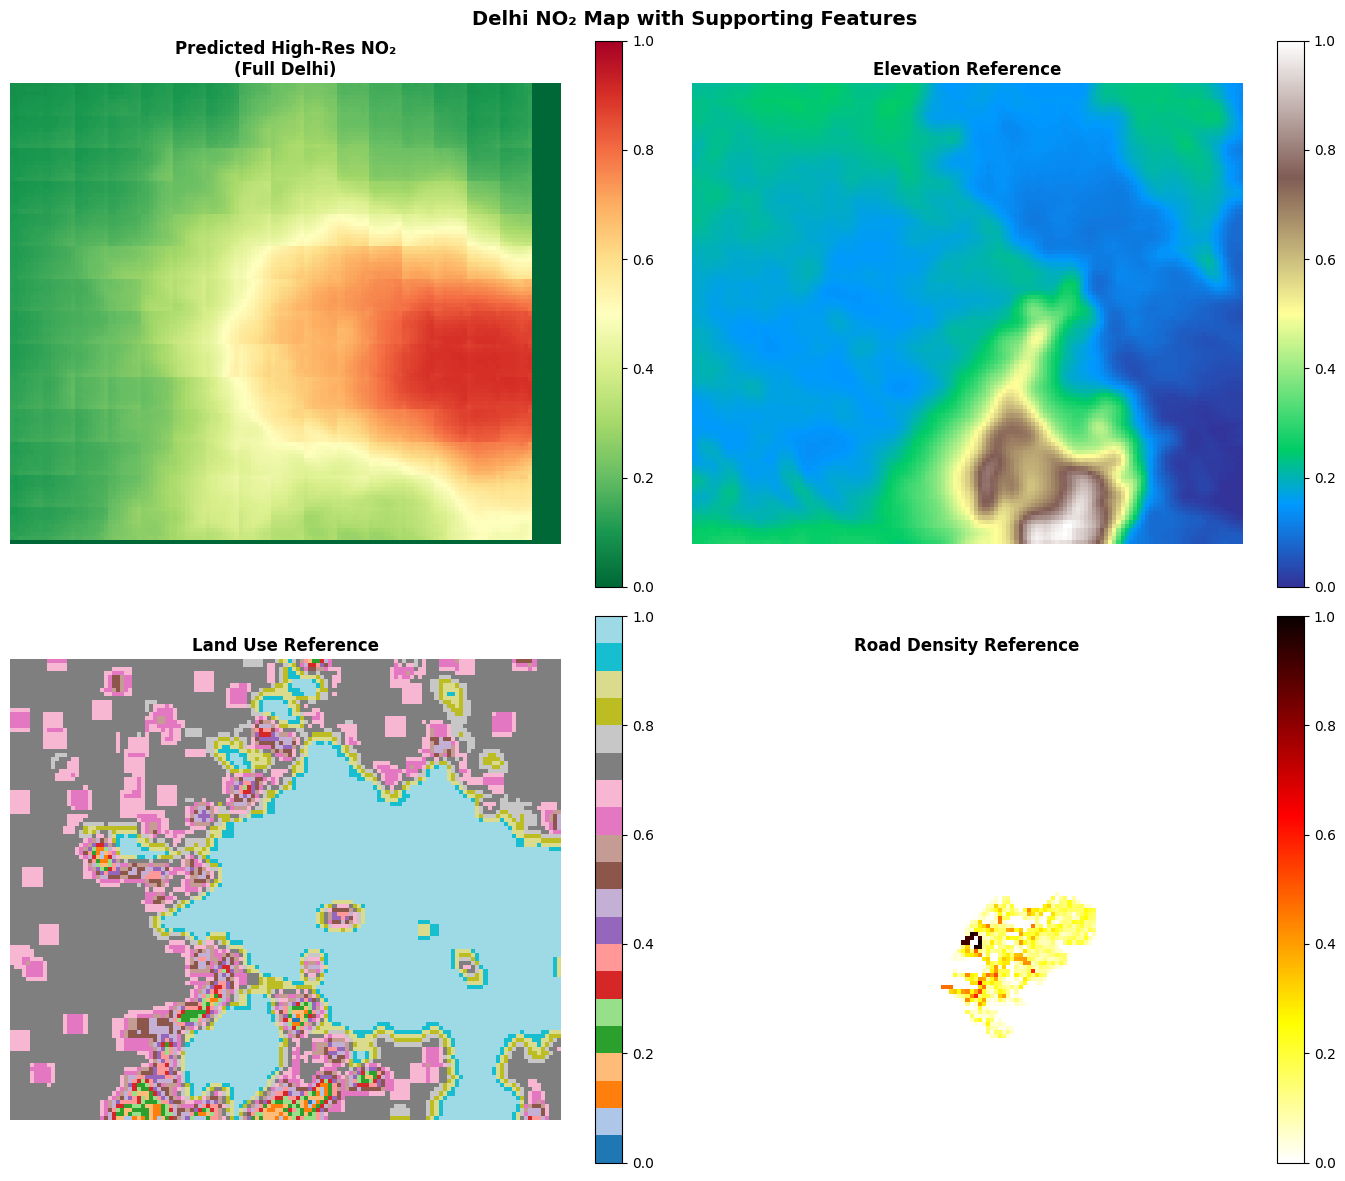

✅ Detailed analysis map saved!


In [31]:
# Detailed Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Predicted NO₂ with colorbar
im1 = axes[0,0].imshow(
    no2_predicted,
    cmap='RdYlGn_r', vmin=0, vmax=1
)
axes[0,0].set_title(
    'Predicted High-Res NO₂\n(Full Delhi)',
    fontweight='bold'
)
axes[0,0].axis('off')
plt.colorbar(im1, ax=axes[0,0])

# Elevation for reference
im2 = axes[0,1].imshow(
    normalized_data['elevation'],
    cmap='terrain'
)
axes[0,1].set_title(
    'Elevation Reference',
    fontweight='bold'
)
axes[0,1].axis('off')
plt.colorbar(im2, ax=axes[0,1])

# Land use for reference
im3 = axes[1,0].imshow(
    normalized_data['landuse'],
    cmap='tab20'
)
axes[1,0].set_title(
    'Land Use Reference',
    fontweight='bold'
)
axes[1,0].axis('off')
plt.colorbar(im3, ax=axes[1,0])

# Road density for reference
im4 = axes[1,1].imshow(
    road_normalized,
    cmap='hot_r'
)
axes[1,1].set_title(
    'Road Density Reference',
    fontweight='bold'
)
axes[1,1].axis('off')
plt.colorbar(im4, ax=axes[1,1])

plt.suptitle(
    'Delhi NO₂ Map with Supporting Features',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('outputs/delhi_no2_with_features.png',
            dpi=300, bbox_inches='tight')
plt.show()

print("✅ Detailed analysis map saved!")